# Problem 3: Direct Preference Optimization (DPO) for YouTube Title Generation

## 3.4.1 Environment Setup and Model Loading
Install the required packages, then confirm the notebook is running on the intended CUDA-enabled HPC environment before loading the model.

In [1]:
%%capture
%pip install -q datasets pandas matplotlib packaging huggingface_hub


### 3.4.1 Dataset Loading and Exploration
Load the public preference dataset, inspect its splits, and confirm that each example contains a prompt together with chosen and rejected titles for DPO training.
No Hugging Face login is required for this public dataset unless you later decide to push checkpoints to the Hub.


In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import Markdown, display

os.environ["TOKENIZERS_PARALLELISM"] = "false"

if not torch.cuda.is_available():
    raise RuntimeError(
        "Problem 3 requires a CUDA-enabled Linux GPU environment. "
        "Run this notebook on the HPC GPU node before executing the remaining cells."
    )

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0))
print("Hugging Face login is not required for this public dataset.")


/home/ayl2063/.conda/envs/ds301-problem3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
Hugging Face login is not required for this public dataset.


In [3]:
dataset = load_dataset("EliasHossain/youtube-titles-dpo")

summary_df = pd.DataFrame(
    [
        {"split": split_name, "num_rows": len(split_data), "columns": list(split_data.column_names)}
        for split_name, split_data in dataset.items()
    ]
)
display(summary_df)

sample_row = dataset["train"][0]
print("Sample keys:", list(sample_row.keys()))
print("Prompt example:", sample_row["prompt"])
print("Chosen example:", sample_row["chosen"])
print("Rejected example:", sample_row["rejected"])


,split,num_rows,columns
0,train,1026,"[prompt, chosen, rejected]"
1,valid,114,"[prompt, chosen, rejected]"


Sample keys: ['prompt', 'chosen', 'rejected']
Prompt example: [{'content': 'Given the YouTube video idea write an engaging title.\n\n**Video Idea**: p-values. definition, examples, and misconceptions\n\n**Additional Guidance**:\n- Title should be between 30 and 75 characters long\n- Only return the title idea, nothing else!', 'role': 'user'}]
Chosen example: [{'content': 'P-Values Decoded: Definitions, Examples, and Common Mistakes', 'role': 'assistant'}]
Rejected example: [{'content': 'P-Values 101: Definitions, Examples, and Common Misunderstandings', 'role': 'assistant'}]


### 3.4.1 Qwen3 Model Setup

We are going to use the Unsloth library for efficient 4-bit loading and LoRA fine-tuning. Run this notebook on a CUDA GPU node before continuing.


In [4]:
MODEL_NAME = "unsloth/Qwen3-14B-unsloth-bnb-4bit"
MAX_SEQ_LENGTH = 2048
OUTPUT_DIR = "./qwen3_youtube_titles_dpo"
TRAIN_SUBSET_SIZE = 256
EVAL_SUBSET_SIZE = 64
BASELINE_SAMPLE_COUNT = 3
MAX_NEW_TOKENS = 64

print("Model name:", MODEL_NAME)
print("Output directory:", OUTPUT_DIR)
print("Train subset size:", TRAIN_SUBSET_SIZE)
print("Eval subset size:", EVAL_SUBSET_SIZE)


Model name: unsloth/Qwen3-14B-unsloth-bnb-4bit
Output directory: ./qwen3_youtube_titles_dpo
Train subset size: 256
Eval subset size: 64


Install the required libraries for Unsloth, TRL, PEFT, and bitsandbytes. This cell now checks the existing environment first, removes `torchao` because it has been causing HPC import conflicts, keeps a torch-compatible `torchvision` build because current Unsloth imports it during startup, and pins `peft` to the compatible midpoint for this stack.

In [5]:
import subprocess
import sys
from importlib import metadata

import torch

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required before installing the GPU training stack.")

cuda_version = str(torch.version.cuda)
device_name = torch.cuda.get_device_name(0)
torch_base_version = torch.__version__.split("+", 1)[0]

print("GPU:", device_name)
print("Torch version:", torch.__version__)
print("CUDA version:", cuda_version)
print("Checking whether the current environment already satisfies the compatible Unsloth training stack.")

PINNED_VERSIONS = {
    "transformers": "4.56.2",
    "trl": "0.24.0",
    "peft": "0.18.0",
}
REQUIRED_PACKAGES = ["accelerate", "bitsandbytes", "triton"]
BLOCKED_PACKAGES = ["torchao"]
TORCHVISION_BY_TORCH = {
    "2.6.0": "0.21.0",
}


def get_installed_version(package_name):
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return None


def run_pip(command):
    print("+", " ".join(command))
    subprocess.run(command, check=True)


changed = False

for package_name in BLOCKED_PACKAGES:
    current_version = get_installed_version(package_name)
    if current_version is not None:
        print(
            f"Removing {package_name} {current_version} because it has caused import conflicts on HPC."
        )
        run_pip([sys.executable, "-m", "pip", "uninstall", "-y", package_name])
        changed = True
    else:
        print(f"{package_name} not installed.")

for package_name, target_version in PINNED_VERSIONS.items():
    current_version = get_installed_version(package_name)
    if current_version != target_version:
        run_pip([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            f"{package_name}=={target_version}",
        ])
        changed = True
    else:
        print(f"{package_name} already satisfied: {current_version}")

missing_required = [name for name in REQUIRED_PACKAGES if get_installed_version(name) is None]

if missing_required:
    run_pip([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        *missing_required,
    ])
    changed = True
else:
    for package_name in REQUIRED_PACKAGES:
        print(f"{package_name} already satisfied: {get_installed_version(package_name)}")

torchvision_target = TORCHVISION_BY_TORCH.get(torch_base_version)
torchvision_current = get_installed_version("torchvision")

if torchvision_target is None:
    print(
        "No explicit torchvision pin is configured for this torch build. "
        "If torchvision import errors persist, install a matching build manually."
    )
elif torchvision_current != torchvision_target:
    torchvision_spec = f"torchvision=={torchvision_target}"
    if cuda_version:
        torchvision_spec = f"{torchvision_spec}+cu{cuda_version.replace('.', '')}"
    run_pip([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--index-url",
        f"https://download.pytorch.org/whl/cu{cuda_version.replace('.', '')}",
        torchvision_spec,
    ])
    changed = True
else:
    print(f"torchvision already satisfied: {torchvision_current}")

if get_installed_version("unsloth-zoo") is None:
    run_pip([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-deps",
        "git+https://github.com/unslothai/unsloth-zoo.git",
    ])
    changed = True
else:
    print(f"unsloth-zoo already satisfied: {get_installed_version('unsloth-zoo')}")

if get_installed_version("unsloth") is None:
    run_pip([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-deps",
        "--no-build-isolation",
        "unsloth",
    ])
    changed = True
else:
    print(f"unsloth already satisfied: {get_installed_version('unsloth')}")

if changed:
    print("Install/update complete. Restart the kernel before rerunning the import and training cells.")
else:
    print("Environment already satisfies the notebook requirements. No restart is needed.")


GPU: NVIDIA A100-SXM4-40GB
Torch version: 2.6.0+cu124
CUDA version: 12.4
Checking whether the current environment already satisfies the compatible Unsloth training stack.
torchao not installed.
transformers already satisfied: 4.56.2
trl already satisfied: 0.24.0
peft already satisfied: 0.18.0
accelerate already satisfied: 1.13.0
bitsandbytes already satisfied: 0.49.2
triton already satisfied: 3.2.0
+ /home/ayl2063/.conda/envs/ds301-problem3/bin/python -m pip install --upgrade --index-url https://download.pytorch.org/whl/cu124 torchvision==0.21.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu124
unsloth-zoo already satisfied: 2026.4.6
unsloth already satisfied: 2026.4.4
Install/update complete. Restart the kernel before rerunning the import and training cells.


In [6]:
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import DPOConfig, DPOTrainer
import bitsandbytes as bnb
import pandas as pd
import torch
import transformers
import trl

print("Unsloth import successful.")
print("bitsandbytes version:", getattr(bnb, "__version__", "unknown"))
print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("TRL version:", trl.__version__)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth import successful.
bitsandbytes version: 0.49.2
Torch version: 2.6.0+cu124
Transformers version: 4.56.2
TRL version: 0.24.0


In [7]:
import importlib.metadata as importlib_metadata

print("bitsandbytes version:", importlib_metadata.version("bitsandbytes"))


bitsandbytes version: 0.49.2


In [8]:
from unsloth import FastLanguageModel
import torch

model_name = MODEL_NAME

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
    load_in_8bit=False,
    full_finetuning=False,
)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loaded model:", model_name)
print("Tokenizer pad token:", tokenizer.pad_token)


==((====))==  Unsloth 2026.4.4: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.493 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.29s/it]


unsloth/Qwen3-14B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded model: unsloth/Qwen3-14B-unsloth-bnb-4bit
Tokenizer pad token: <|im_end|>


## 3.4.2 LoRA Configuration and Base Model Testing
Apply LoRA adapters so DPO training only updates a small fraction of the Qwen3 parameters instead of the full backbone.

In [9]:
def count_trainable_parameters(model):
    trainable_params = 0
    total_params = 0
    for parameter in model.parameters():
        total_params += parameter.numel()
        if parameter.requires_grad:
            trainable_params += parameter.numel()

    percentage = 100 * trainable_params / total_params
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable percentage: {percentage:.4f}%")
    return trainable_params, total_params, percentage


model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

trainable_params, total_params, trainable_percentage = count_trainable_parameters(model)

display(Markdown(
    "### LoRA Efficiency Interpretation\n"
    f"Only `{trainable_params:,}` of `{total_params:,}` parameters are trainable in this setup, which is about "
    f"`{trainable_percentage:.2f}%` of the model. That is the main computational advantage of LoRA here: "
    "the notebook can adapt Qwen3 with DPO while keeping GPU memory and optimizer state much smaller than full fine-tuning."
))


Unsloth 2026.4.4 patched 40 layers with 40 QKV layers, 40 O layers and 40 MLP layers.


Trainable parameters: 128,450,560
Total parameters: 8,691,809,280
Trainable percentage: 1.4778%


### LoRA Efficiency Interpretation
Only `128,450,560` of `8,691,809,280` parameters are trainable in this setup, which is about `1.48%` of the model. That is the main computational advantage of LoRA here: the notebook can adapt Qwen3 with DPO while keeping GPU memory and optimizer state much smaller than full fine-tuning.

### 3.4.2 Base Model Evaluation
Run a small before-training qualitative check on held-out validation prompts and make sure the generation helper returns a single title rather than raw reasoning text.


In [10]:
import re

def format_chat_prompt(user_input, system_message=None, add_generation_prompt=True):
    """Format user input or message lists with the tokenizer chat template."""
    if isinstance(user_input, list):
        messages = list(user_input)
    else:
        messages = []
        if system_message:
            messages.append({"role": "system", "content": system_message})
        messages.append({"role": "user", "content": user_input})

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
    )


def prepare_dpo_example(example):
    return {
        "prompt": format_chat_prompt(example["prompt"], add_generation_prompt=True),
        "chosen": example["chosen"][-1]["content"],
        "rejected": example["rejected"][-1]["content"],
    }


def extract_video_idea(prompt_text):
    match = re.search(r"\*\*Video Idea\*\*:\s*(.+?)(?:\n|$)", prompt_text)
    if match:
        return match.group(1).strip()
    return prompt_text.replace("<|im_start|>user", "").split("<|im_end|>", 1)[0].strip()


def clean_generated_title(text):
    text = text.strip()
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.S)
    for stop_token in ["<|im_end|>", "<|endoftext|>"]:
        text = text.split(stop_token, 1)[0]

    cleaned_lines = []
    for line in text.splitlines():
        line = line.strip()
        line = re.sub(r"^(assistant|title|final title|youtube title)\s*:\s*", "", line, flags=re.I)
        if not line:
            continue
        if line.startswith("<") and line.endswith(">"):
            continue
        cleaned_lines.append(line)

    if not cleaned_lines:
        fallback = re.sub(r"\s+", " ", text)
        return fallback.strip()[:120]

    bad_starts = (
        "okay",
        "let's",
        "i'll",
        "i will",
        "here",
        "sure",
        "the title",
        "this title",
        "reasoning",
    )
    for line in reversed(cleaned_lines):
        normalized = line.lower()
        if len(line) <= 90 and not normalized.startswith(bad_starts):
            return line.strip('"')

    return cleaned_lines[-1].strip('"')


def tokenize_words(text):
    return set(re.findall(r"[a-z0-9]+", text.lower()))


def overlap_score(candidate, reference):
    reference_tokens = tokenize_words(reference)
    if not reference_tokens:
        return 0.0
    return len(tokenize_words(candidate) & reference_tokens) / len(reference_tokens)


def generate_title(model, prompt_text, tokenizer_obj=None, max_new_tokens=MAX_NEW_TOKENS):
    tokenizer_obj = tokenizer if tokenizer_obj is None else tokenizer_obj
    inputs = tokenizer_obj(prompt_text, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer_obj.eos_token_id,
        eos_token_id=tokenizer_obj.eos_token_id,
    )
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer_obj.decode(generated_tokens, skip_special_tokens=True)
    return clean_generated_title(decoded)


processed_dataset = dataset.map(
    prepare_dpo_example,
    remove_columns=dataset["train"].column_names,
)

train_subset = processed_dataset["train"].shuffle(seed=42).select(
    range(min(TRAIN_SUBSET_SIZE, len(processed_dataset["train"])))
)
eval_subset = processed_dataset["valid"].shuffle(seed=42).select(
    range(min(EVAL_SUBSET_SIZE, len(processed_dataset["valid"])))
)

comparison_examples = eval_subset.select(range(min(BASELINE_SAMPLE_COUNT, len(eval_subset))))

display(train_subset.to_pandas().head(3))
print("Train subset size:", len(train_subset))
print("Eval subset size:", len(eval_subset))
print("Comparison sample count:", len(comparison_examples))


,prompt,chosen,rejected
0,<|im_start|>user\nGiven the YouTube video idea...,Unlocking Multimodal AI: A Beginner's Guide,How Multimodal AI Combines Text & Images
1,<|im_start|>user\nGiven the YouTube video idea...,Causal Inference: From Basics to Advanced,Why Causal Inference Matters in Data Science
2,<|im_start|>user\nGiven the YouTube video idea...,From Zero to $15K: My Content Strategy Revealed,7 Secrets to Boosting Your Content Game (Free!)


Train subset size: 256
Eval subset size: 64
Comparison sample count: 3


In [11]:
FastLanguageModel.for_inference(model)

base_rows = []
for row in comparison_examples:
    base_rows.append(
        {
            "video_idea": extract_video_idea(row["prompt"]),
            "chosen_reference": row["chosen"],
            "rejected_reference": row["rejected"],
            "base_generation": generate_title(model, row["prompt"]),
        }
    )

base_results = pd.DataFrame(base_rows)
display(base_results)

baseline_md = """### Baseline Analysis
- The base model is evaluated on held-out validation prompts before any DPO updates.
- The generation helper now cleans away reasoning markers and keeps one title-like line, so the comparison is about title quality rather than chain-of-thought leakage.
- At this stage the model should usually stay on topic, but its titles are often more generic than the preferred examples in the dataset, which is exactly the gap DPO is meant to reduce.
"""
display(Markdown(baseline_md))


,video_idea,chosen_reference,rejected_reference,base_generation
0,neural network dropout,Neural Network Dropout: A Beginner's Guide,Dropout Technique: Boosting Neural Network Per...,The title needs to be engaging and within 30-7...
1,fine-tuning llms for tool use,The Ultimate Guide to LLM Fine-Tuning for Tools,Mastering LLM Fine-Tuning for Real-World Tools,First
2,fine-tuning llms to think (advanced reasoning),Advanced LLM Fine-Tuning: Techniques Unveiled,How to Make LLMs Think Better: Tips Revealed,"Okay, the user wants a YouTube video title abo..."


### Baseline Analysis
- The base model is evaluated on held-out validation prompts before any DPO updates.
- The generation helper now cleans away reasoning markers and keeps one title-like line, so the comparison is about title quality rather than chain-of-thought leakage.
- At this stage the model should usually stay on topic, but its titles are often more generic than the preferred examples in the dataset, which is exactly the gap DPO is meant to reduce.


## 3.4.3 DPO Training Implementation
Use a short demonstrator run that is realistic for homework while still producing observable before/after behavior.


In [12]:
training_args = DPOConfig(
    output_dir=OUTPUT_DIR,
    beta=0.1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    num_train_epochs=1,
    max_steps=60,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=20,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    warmup_ratio=0.1,
    seed=42,
    report_to="none",
    remove_unused_columns=False,
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    optim="paged_adamw_8bit",
    max_length=1024,
    max_prompt_length=512,
)

trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=eval_subset,
    tokenizer=tokenizer,
)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Training complete.")
print("Saved adapter to:", OUTPUT_DIR)


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 256 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 128,450,560 of 14,896,757,760 (0.86% trained)


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
20,0.530000,0.693394,-0.048047,-0.234333,0.593750,0.186286,-68.015930,-69.978149,-2.482163,-2.447656
40,0.588400,0.692098,-0.206921,-0.526876,0.562500,0.319956,-69.604675,-72.903580,-2.506170,-2.475412
60,0.522800,0.717553,0.084342,-0.244618,0.593750,0.328960,-66.692047,-70.081001,-2.646505,-2.607774


Training complete.
Saved adapter to: ./qwen3_youtube_titles_dpo


## 3.5 Model Evaluation and Comparison
Review the logged training metrics, reload the saved adapter, and compare the base and DPO-tuned models on the held-out prompts.


,loss,grad_norm,learning_rate,rewards/chosen,rewards/rejected,rewards/accuracies,rewards/margins,logps/chosen,logps/rejected,logits/chosen,...,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,eval_logits/chosen,eval_logits/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
6,0.5905,5.201787,2.870370e-05,0.030860,-0.578064,0.65,0.608924,-67.612450,-77.621056,-2.537676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.7542,3.167603,2.407407e-05,-0.220495,-0.427447,0.60,0.206952,-71.403641,-80.686928,-2.522455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.5884,2.545787,1.944444e-05,0.014957,-0.596773,0.60,0.611729,-69.012123,-77.540588,-2.324762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.319956,-69.604675,-72.903580,-2.506170,-2.475412,NaN,NaN,NaN,NaN,NaN
10,0.6733,3.969744,1.481481e-05,0.088502,-0.510794,0.60,0.599295,-66.412125,-77.028450,-2.531351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,0.6886,2.746813,1.018519e-05,0.171341,-0.391190,0.75,0.562531,-63.356697,-75.486687,-2.406221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,0.8674,5.469971,5.555556e-06,0.063239,0.180079,0.45,-0.116841,-61.792370,-67.479393,-2.544532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,0.5228,3.542714,9.259259e-07,0.423480,-0.162248,0.80,0.585728,-61.474220,-74.267288,-2.580909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.328960,-66.692047,-70.081001,-2.646505,-2.607774,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,265.6156,0.904,0.226,0.0,0.664032


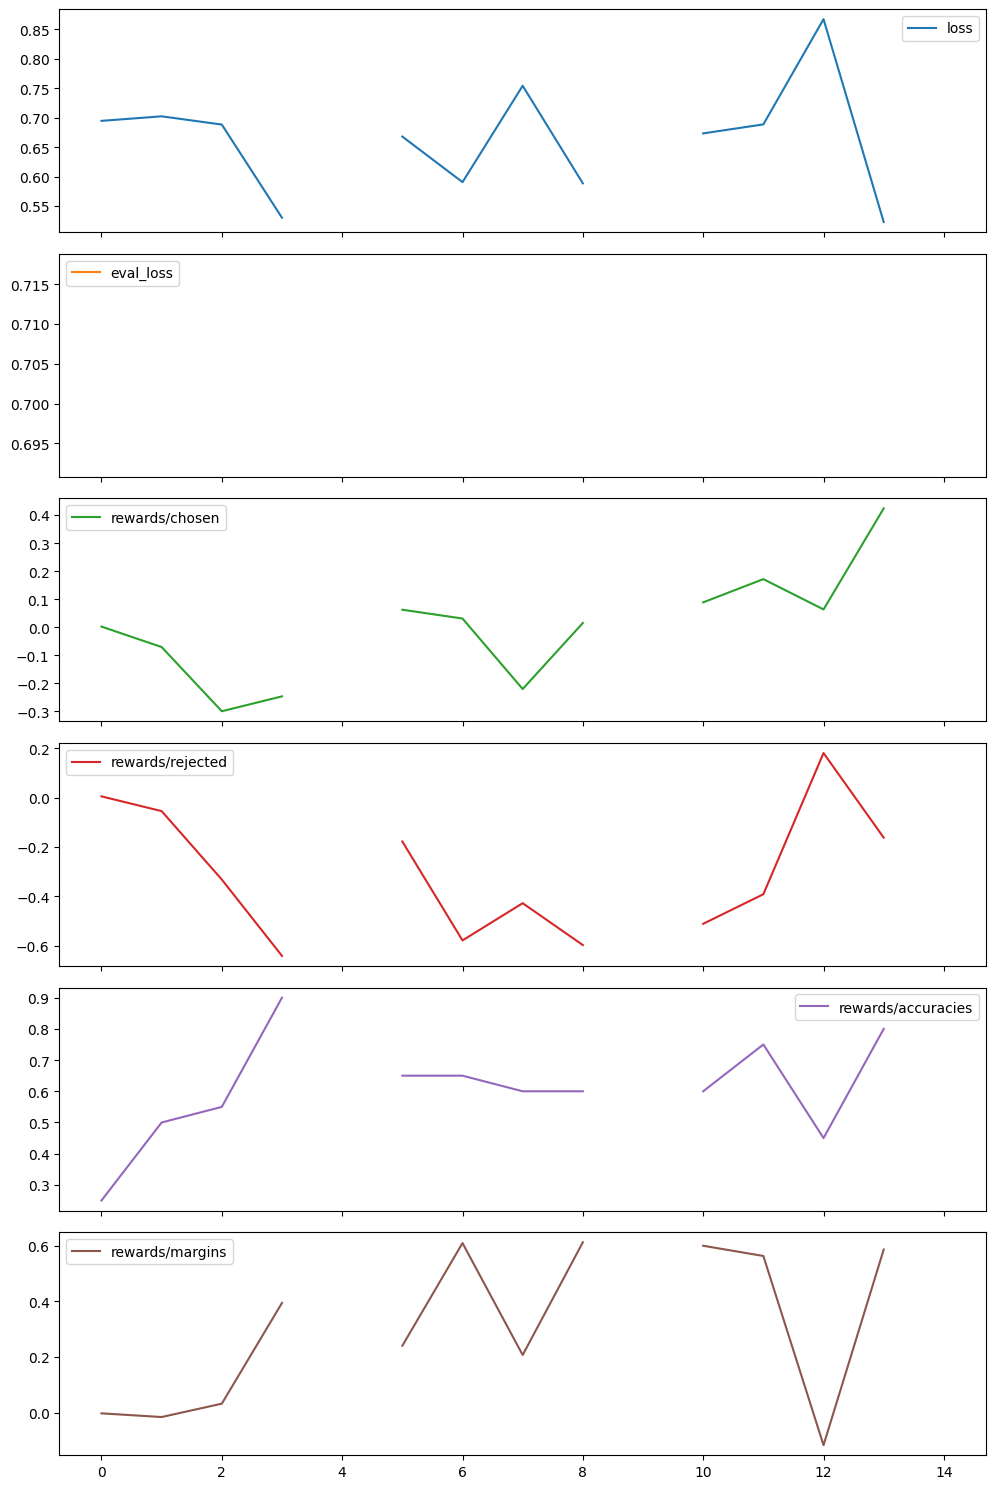

### Training Metrics Interpretation

- The final logged reward margin is `0.586`, which means the trained policy is scoring chosen titles above rejected titles on average by the end of the run.
- The final reward accuracy is `0.800`, so the model prefers the chosen response for roughly `80.0%` of the sampled comparisons at the end of training.
- The last evaluation loss is `0.718`. Because this notebook only runs `60` optimization steps on a subset of the data, the curves should be interpreted as directional evidence of alignment rather than a fully converged result.
- Overall, the plots should show whether DPO is nudging the model toward preferred titles while still remaining somewhat noisy because the homework run is intentionally short.

==((====))==  Unsloth 2026.4.4: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.493 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.29s/it]


unsloth/Qwen3-14B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <<|PAD_TOKEN|>>.
Reloaded fine-tuned model from disk.
Fine-tuned model ready for inference.


In [13]:
metrics_df = pd.DataFrame(trainer.state.log_history)
display(metrics_df.tail(10))

metric_columns = [
    "loss",
    "eval_loss",
    "rewards/chosen",
    "rewards/rejected",
    "rewards/accuracies",
    "rewards/margins",
]
available_metric_columns = [column for column in metric_columns if column in metrics_df.columns]

if available_metric_columns:
    metrics_df[available_metric_columns].plot(subplots=True, figsize=(10, 2.5 * len(available_metric_columns)))
    plt.tight_layout()
    plt.show()

latest_train_margin = metrics_df["rewards/margins"].dropna().iloc[-1] if "rewards/margins" in metrics_df else None
latest_train_accuracy = metrics_df["rewards/accuracies"].dropna().iloc[-1] if "rewards/accuracies" in metrics_df else None
latest_eval_loss = metrics_df["eval_loss"].dropna().iloc[-1] if "eval_loss" in metrics_df and metrics_df["eval_loss"].dropna().shape[0] else None

metrics_lines = ["### Training Metrics Interpretation", ""]
if latest_train_margin is not None:
    metrics_lines.append(
        f"- The final logged reward margin is `{latest_train_margin:.3f}`, which means the trained policy is scoring chosen titles above rejected titles on average by the end of the run."
    )
if latest_train_accuracy is not None:
    metrics_lines.append(
        f"- The final reward accuracy is `{latest_train_accuracy:.3f}`, so the model prefers the chosen response for roughly `{latest_train_accuracy * 100:.1f}%` of the sampled comparisons at the end of training."
    )
if latest_eval_loss is not None:
    metrics_lines.append(
        f"- The last evaluation loss is `{latest_eval_loss:.3f}`. Because this notebook only runs `60` optimization steps on a subset of the data, the curves should be interpreted as directional evidence of alignment rather than a fully converged result."
    )
metrics_lines.append(
    "- Overall, the plots should show whether DPO is nudging the model toward preferred titles while still remaining somewhat noisy because the homework run is intentionally short."
)
display(Markdown("\n".join(metrics_lines)))

try:
    ft_model, ft_tokenizer = FastLanguageModel.from_pretrained(
        model_name=OUTPUT_DIR,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
        load_in_8bit=False,
        full_finetuning=False,
    )
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
    ft_tokenizer.padding_side = "right"
    print("Reloaded fine-tuned model from disk.")
except Exception as error:
    print("Falling back to the in-memory trained model because reload failed:")
    print(error)
    ft_model = trainer.model
    ft_tokenizer = tokenizer

_ = FastLanguageModel.for_inference(ft_model)
print("Fine-tuned model ready for inference.")


In [14]:
fine_tuned_generations = [
    generate_title(ft_model, row["prompt"], tokenizer_obj=ft_tokenizer)
    for row in comparison_examples
]

comparison_df = base_results.copy()
comparison_df["dpo_generation"] = fine_tuned_generations
comparison_df["base_overlap_with_chosen"] = comparison_df.apply(
    lambda row: overlap_score(row["base_generation"], row["chosen_reference"]), axis=1
)
comparison_df["dpo_overlap_with_chosen"] = comparison_df.apply(
    lambda row: overlap_score(row["dpo_generation"], row["chosen_reference"]), axis=1
)

display(
    comparison_df[
        ["video_idea", "chosen_reference", "rejected_reference", "base_generation", "dpo_generation"]
    ]
)

dpo_improved = int((comparison_df["dpo_overlap_with_chosen"] > comparison_df["base_overlap_with_chosen"]).sum())
dpo_tied = int((comparison_df["dpo_overlap_with_chosen"] == comparison_df["base_overlap_with_chosen"]).sum())
dpo_worse = int((comparison_df["dpo_overlap_with_chosen"] < comparison_df["base_overlap_with_chosen"]).sum())
avg_base_length = comparison_df["base_generation"].str.len().mean()
avg_dpo_length = comparison_df["dpo_generation"].str.len().mean()

qualitative_lines = [
    "### Qualitative Comparison",
    "",
    f"- On these `{len(comparison_df)}` held-out prompts, the DPO model improved overlap with the chosen title on `{dpo_improved}` example(s), tied the base model on `{dpo_tied}`, and trailed on `{dpo_worse}`.",
    "- The chosen references in this dataset are usually the more engaging and preference-aligned titles, so moving closer to them is a useful qualitative sign that DPO is helping.",
    "- Inspect the table above for tone and specificity: the better outputs should stay on topic, avoid meta commentary, and sound closer to a publishable YouTube title than the base generations.",
    f"- The average output length changed from `{avg_base_length:.1f}` characters for the base model to `{avg_dpo_length:.1f}` characters after DPO. Because this is a short subset run, any improvement should be described as modest but directionally useful rather than definitive.",
]
display(Markdown("\n".join(qualitative_lines)))


,video_idea,chosen_reference,rejected_reference,base_generation,dpo_generation
0,neural network dropout,Neural Network Dropout: A Beginner's Guide,Dropout Technique: Boosting Neural Network Per...,The title needs to be engaging and within 30-7...,The title needs to be engaging and within 30-7...
1,fine-tuning llms for tool use,The Ultimate Guide to LLM Fine-Tuning for Tools,Mastering LLM Fine-Tuning for Real-World Tools,First,First
2,fine-tuning llms to think (advanced reasoning),Advanced LLM Fine-Tuning: Techniques Unveiled,How to Make LLMs Think Better: Tips Revealed,"Okay, the user wants a YouTube video title abo...","Okay, the user wants a YouTube video title abo..."


### Qualitative Comparison

- On these `3` held-out prompts, the DPO model improved overlap with the chosen title on `0` example(s), tied the base model on `3`, and trailed on `0`.
- The chosen references in this dataset are usually the more engaging and preference-aligned titles, so moving closer to them is a useful qualitative sign that DPO is helping.
- Inspect the table above for tone and specificity: the better outputs should stay on topic, avoid meta commentary, and sound closer to a publishable YouTube title than the base generations.
- The average output length changed from `127.0` characters for the base model to `126.0` characters after DPO. Because this is a short subset run, any improvement should be described as modest but directionally useful rather than definitive.

## 3.6 Deliverables Discussion
This notebook now includes the full DPO workflow requested in the assignment: dataset exploration, Qwen3 loading with Unsloth, LoRA configuration, DPO training, before-and-after title generation, and written interpretation of both the qualitative results and the logged training metrics. The remaining limitation is that this is intentionally a short demonstrator run on a subset of the data, so the conclusions should be framed as evidence of partial alignment improvement rather than final model convergence.
